In [4]:
import h5py as h5
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.models as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import csv
from torchvision.models import resnet18
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from PIL import Image
import h5py
device = 'cuda' if torch.cuda.is_available() else 'cpu'
import warnings 
warnings.filterwarnings("ignore")

In [5]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
data = h5py.File('/kaggle/input/rotated-mnist-dataset/mnist_rotated_pair.h5', 'r')
metadata = pd.read_csv('/kaggle/input/rotated-mnist-dataset/mnist_rotated_pair_metadata.csv')

In [7]:
data.keys()

<KeysViewHDF5 ['angle_rotated', 'labels', 'original_images', 'rotated_images']>

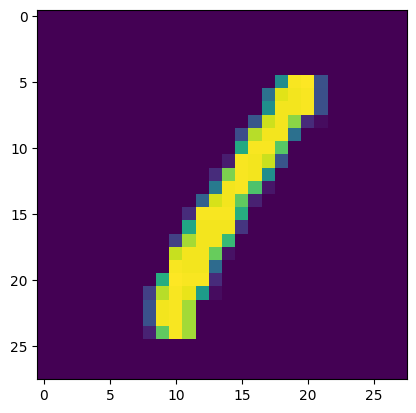

In [8]:
plt.imshow(data['rotated_images'][0])

In [9]:
class VAEDataset:
    def __init__(self,data,transform):
        self.data = data
        self.transform = transform
    def __len__(self):
        return len(self.data['rotated_images'])
    def __getitem__(self,idx):
        rotated_img = self.data['rotated_images'][idx]
        original_img = self.data['original_images'][idx]
        angle = self.data['angle_rotated'][idx]
        label = self.data['labels'][idx]
        # rotated_img = np.repeat(rotated_img[:,:,np.newaxis],3,axis = -1)
        # original_img = np.repeat(original_img[:,:,np.newaxis],3,axis = -1)
        if self.transform != None:
            rotated_img = self.transform(image = rotated_img)['image']
        return rotated_img, original_img, label, angle

In [10]:
transform = A.Compose([
    ToTensorV2(),
])

In [11]:
dataset = VAEDataset(data,transform)
dataloader = DataLoader(dataset, batch_size = 64, shuffle = True, num_workers = os.cpu_count())

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]
Epoch 1/5: 100%|██████████| 2788/2788 [01:51<00:00, 24.91it/s]


Epoch [1/5] Loss: 143.9284


Epoch 2/5: 100%|██████████| 2788/2788 [01:49<00:00, 25.52it/s]


Epoch [2/5] Loss: 130.3637


Epoch 3/5: 100%|██████████| 2788/2788 [01:49<00:00, 25.55it/s]


Epoch [3/5] Loss: 128.0325


Epoch 4/5: 100%|██████████| 2788/2788 [01:49<00:00, 25.51it/s]


Epoch [4/5] Loss: 126.0658


Epoch 5/5: 100%|██████████| 2788/2788 [01:49<00:00, 25.38it/s]

Epoch [5/5] Loss: 124.6291


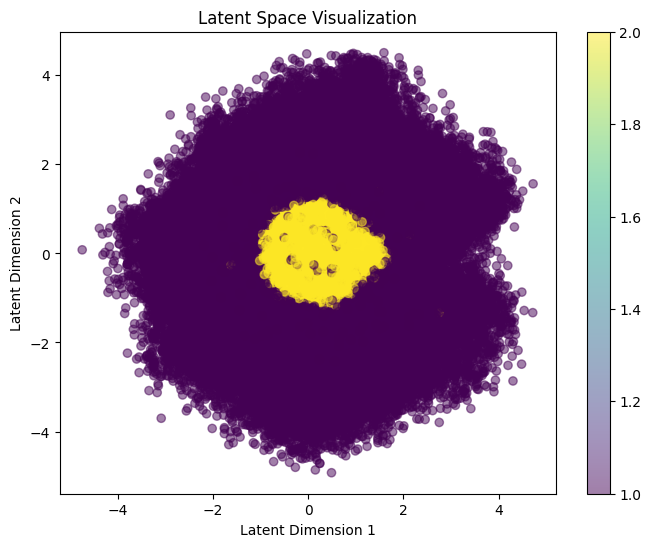

In [12]:
class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()
        resnet = models.resnet18(pretrained=True)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity() 
        self.encoder = nn.Sequential(
            resnet.conv1,   
            resnet.bn1,
            resnet.relu,
            resnet.layer1,  
            resnet.layer2,  
            resnet.layer3,  
            resnet.layer4,  
            resnet.avgpool, 
            nn.Flatten()    
        )
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 64 * 7 * 7)
        
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),  
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        h_decode = self.fc_decode(z)
        x_recon = self.decoder(h_decode)
        return x_recon, mu, logvar

model = VAE(latent_dim=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

from tqdm import tqdm
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for rotated, original, labels, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        rotated = rotated.to(device).float() / 255.0
        optimizer.zero_grad()
        recon, mu, logvar = model(rotated)
        recon_loss = F.binary_cross_entropy(recon, rotated, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + kl_loss
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(dataloader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

model.eval()
all_latents, all_labels = [], []
with torch.no_grad():
    for rotated, original, labels, _ in dataloader:
        rotated = rotated.to(device).float() / 255.0
        _, mu, _ = model(rotated)
        all_latents.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())
all_latents = np.concatenate(all_latents, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(all_latents[:, 0], all_latents[:, 1], c=all_labels, cmap='viridis', alpha=0.5)
plt.colorbar(scatter)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Latent Space Visualization")
plt.show()

In [13]:
torch.save({'model_state_dict':model.state_dict()},'VAE.pth')

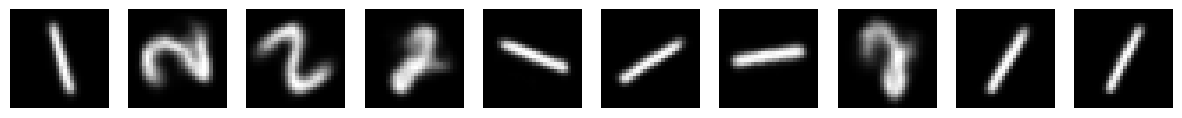

In [14]:
model.eval()

num_samples = 10
latent_dim = 2

with torch.no_grad():
    z = torch.randn(num_samples, latent_dim).to(device)
    # z = torch.zeros(num_samples,2).to(device)
    generated_images = model.decoder(model.fc_decode(z)).cpu()

fig, axes = plt.subplots(1, num_samples, figsize=(15, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(generated_images[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.show()

Correlation of latent dimensions with rotation angle:
Latent dim 0: corr = -0.196, p-value = 0.000e+00
Latent dim 1: corr = -0.090, p-value = 1.270e-318


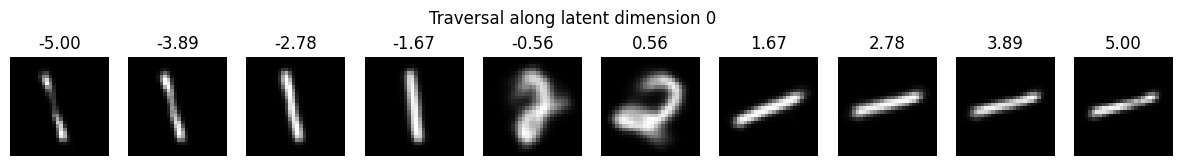

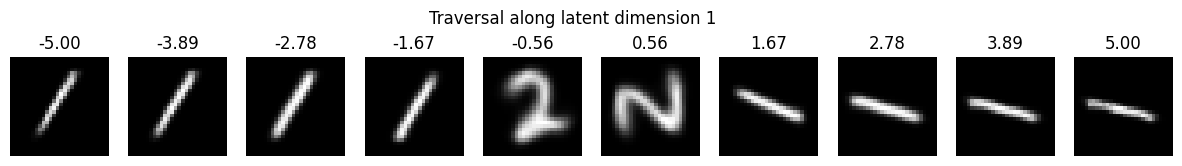

In [15]:
from scipy.stats import pearsonr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

all_latents = []
all_angles = []
with torch.no_grad():
    for rotated, original, labels, angles_batch in tqdm(dataloader, desc="Collecting Latents"):
        rotated = rotated.to(device).float() / 255.0
        _, mu, _ = model(rotated)
        all_latents.append(mu.cpu().numpy())
        all_angles.append(angles_batch.numpy())
        
all_latents = np.concatenate(all_latents, axis=0)
all_angles = np.concatenate(all_angles, axis=0)

latent_dim = all_latents.shape[1]
print("Correlation of latent dimensions with rotation angle:")
for i in range(latent_dim):
    corr, p_value = pearsonr(all_latents[:, i], all_angles)
    print(f"Latent dim {i}: corr = {corr:.3f}, p-value = {p_value:.3e}")

sample_latent = all_latents[1]
num_steps = 10
traversal_range = np.linspace(-5, 5, num_steps)

traversed_images = []
for dim in range(latent_dim):
    images_for_dim = []
    for value in traversal_range:
        z_new = sample_latent.copy()
        z_new[dim] = value
        z_new_tensor = torch.tensor(z_new).unsqueeze(0).to(device).float()
        with torch.no_grad():
            h_decode = model.fc_decode(z_new_tensor)
            generated = model.decoder(h_decode).cpu().squeeze().numpy()
        images_for_dim.append(generated)
    traversed_images.append(images_for_dim)

for dim in range(latent_dim):
    fig, axes = plt.subplots(1, num_steps, figsize=(num_steps*1.5, 2))
    for j in range(num_steps):
        axes[j].imshow(traversed_images[dim][j], cmap='gray')
        axes[j].set_title(f"{traversal_range[j]:.2f}")
        axes[j].axis('off')
    plt.suptitle(f"Traversal along latent dimension {dim}")
    plt.show()

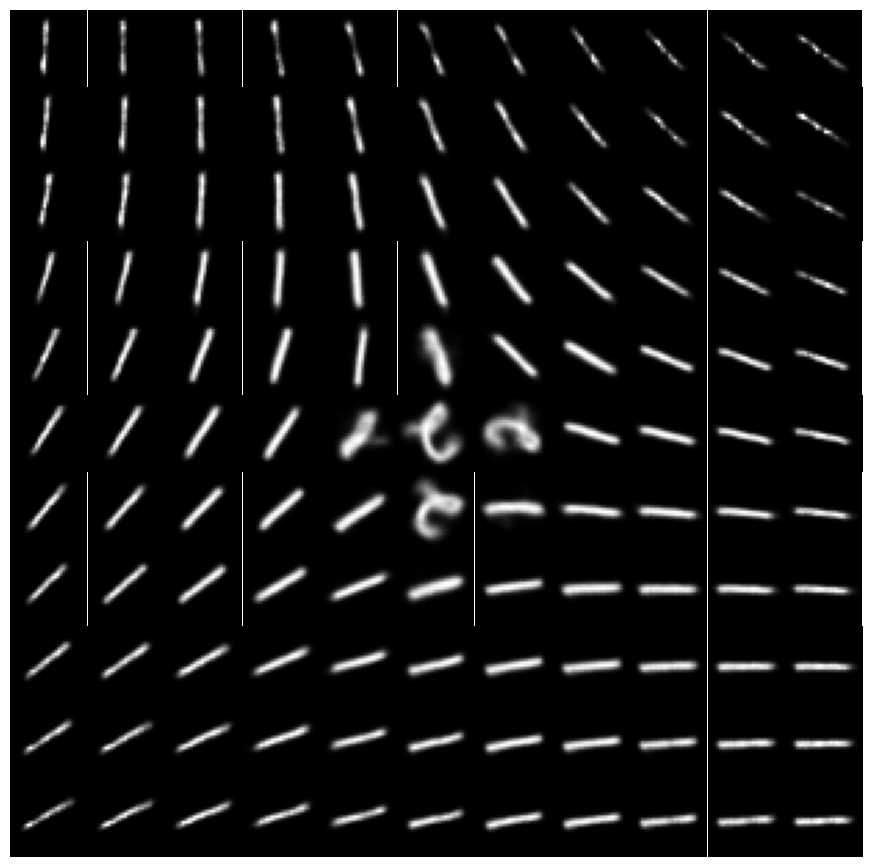

In [16]:
latent_mean = np.mean(all_latents, axis=0)
latent_dim = 2  
grid_size = 11
z0_values = np.linspace(latent_mean[0] - 5, latent_mean[0] + 5, grid_size)
z1_values = np.linspace(latent_mean[1] - 5, latent_mean[1] + 5, grid_size)

fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size, grid_size))

model.eval()
with torch.no_grad():
    for i, z0 in enumerate(z0_values):
        for j, z1 in enumerate(z1_values):
            z = torch.tensor([z0, z1], device=device).unsqueeze(0).float()
            h_decode = model.fc_decode(z)
            x_decoded = model.decoder(h_decode)
            img = x_decoded.cpu().squeeze().numpy()
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

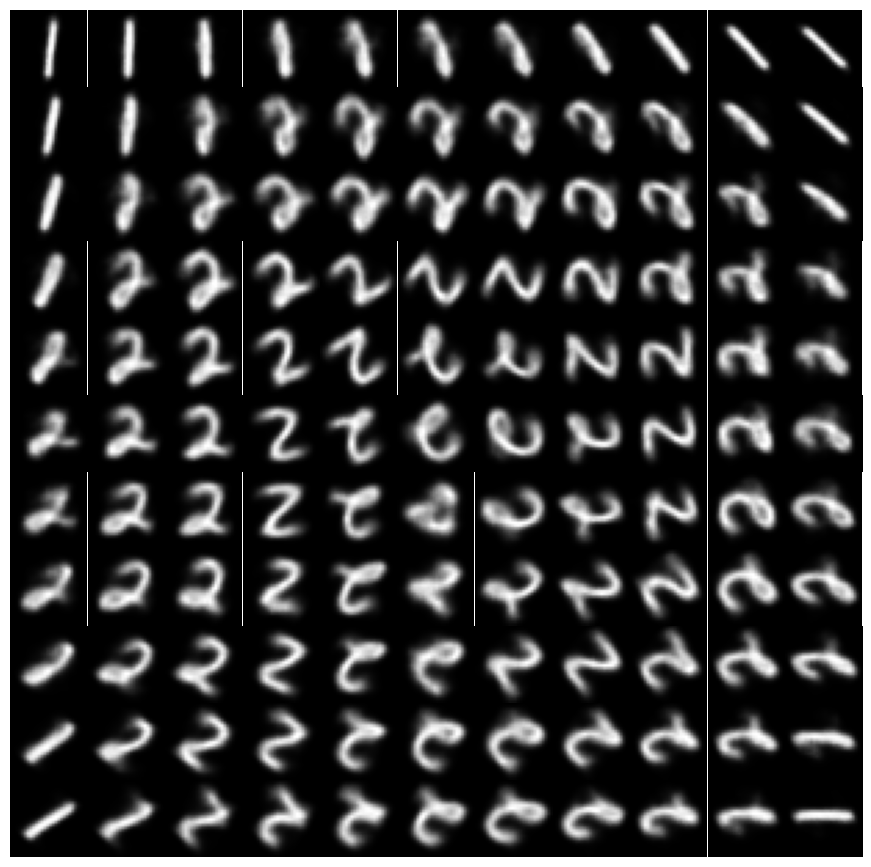

In [17]:
latent_dim = 2
grid_size = 11  
z0_values = np.linspace(-1, 1, grid_size)
z1_values = np.linspace(-1, 1, grid_size)

fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size, grid_size))
model.eval()
with torch.no_grad():
    for i, z0 in enumerate(z0_values):
        for j, z1 in enumerate(z1_values):
            z = torch.tensor([z0, z1], device=device).unsqueeze(0).float()
            h_decode = model.fc_decode(z)
            x_decoded = model.decoder(h_decode)
            img = x_decoded.cpu().squeeze().numpy()
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()